In [2]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = (
    PROJECT_ROOT / "data" / "processed" / "tatarstan_economic_data_clean.csv"
)

df = pd.read_csv(DATA_PATH)
model_df = (df[["year","unemployment_diff","investment_diff","grp_log_growth"]].dropna().reset_index(drop=True))
model_df.head()

,year,unemployment_diff,investment_diff,grp_log_growth
0,2001,-1.3,-6.2,0.141573
1,2002,-1.2,-3.2,0.140145
2,2003,-1.2,4.8,0.158661
3,2004,-0.9,6.5,0.176596
4,2005,-0.6,3.6,0.192881


In [3]:
y = model_df["unemployment_diff"].values
X = model_df[["investment_diff", "grp_log_growth"]].copy()

X_mean = X.mean()
X_std = X.std()
X_scaled = (X - X_mean) / X_std

In [4]:
with pm.Model() as model:
    intercept = pm.Normal(
        "intercept",
        mu=0,
        sigma=1
    )
    beta_investment = pm.Normal(
        "beta_investment",
        mu=0,
        sigma=1
    )
    beta_grp = pm.Normal(
        "beta_grp",
        mu=0,
        sigma=1
    )
    sigma = pm.HalfNormal(
        "sigma",
        sigma=1
    )
    mu = (
        intercept
        + beta_investment * X_scaled["investment_diff"].values
        + beta_grp * X_scaled["grp_log_growth"].values
    )
    unemployment_obs = pm.Normal(
        "unemployment_obs",
        mu=mu,
        sigma=sigma,
        observed=y
    )

    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=2,
        target_accept=0.95,
        random_seed=42
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_investment, beta_grp, sigma]


C:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\rich\live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 22 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [5]:
intercept_mean = trace.posterior["intercept"].mean().item()

beta_investment_mean = (trace.posterior["beta_investment"].mean().item())
beta_grp_mean = (trace.posterior["beta_grp"].mean().item())

y_pred = (intercept_mean+ beta_investment_mean* X_scaled["investment_diff"].values+ beta_grp_mean* X_scaled["grp_log_growth"].values)

validation_df = pd.DataFrame({"year": model_df["year"],"actual": y,"predicted": y_pred})
validation_df.head()

,year,actual,predicted
0,2001,-1.3,-0.534062
1,2002,-1.2,-0.581803
2,2003,-1.2,-0.841109
3,2004,-0.9,-0.978990
4,2005,-0.6,-1.020952


In [7]:
mae = mean_absolute_error(validation_df["actual"],validation_df["predicted"])
rmse = np.sqrt(mean_squared_error(validation_df["actual"],validation_df["predicted"]))

print(f"In-sample MAE: {mae:.4f}")
print(f"In-sample RMSE: {rmse:.4f}")

In-sample MAE: 0.2871
In-sample RMSE: 0.3599


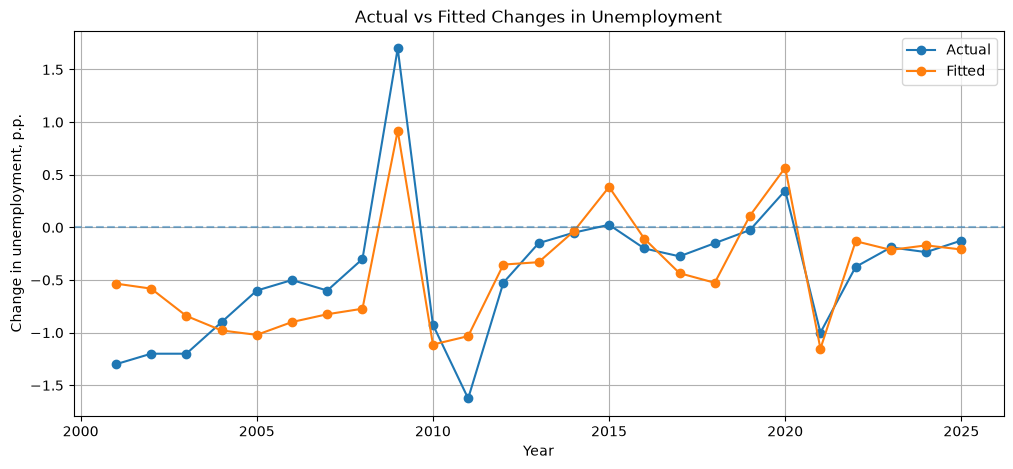

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    validation_df["year"],
    validation_df["actual"],
    marker="o",
    label="Actual"
)

plt.plot(
    validation_df["year"],
    validation_df["predicted"],
    marker="o",
    label="Fitted"
)

plt.axhline(
    y=0,
    linestyle="--",
    alpha=0.5
)

plt.title("Actual vs Fitted Changes in Unemployment")
plt.xlabel("Year")
plt.ylabel("Change in unemployment, p.p.")
plt.legend()
plt.grid(True)

plt.show()

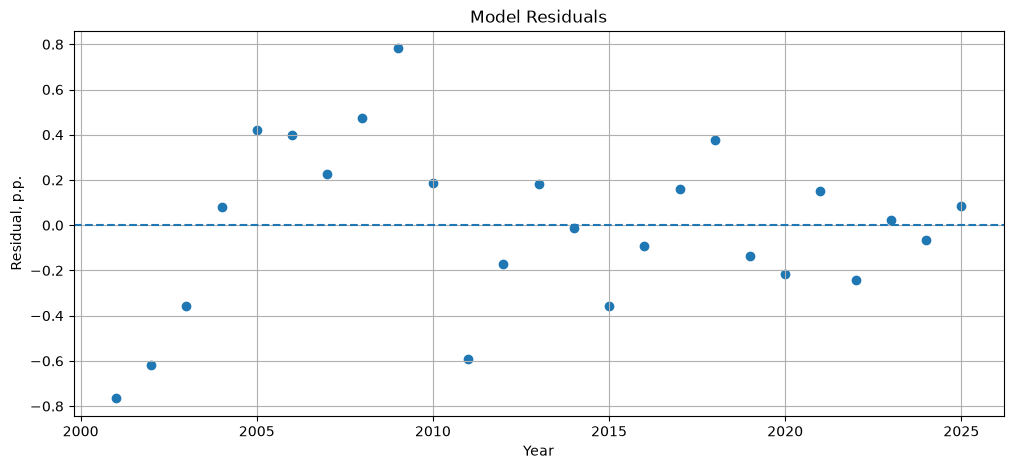

In [9]:
validation_df["residual"] = (validation_df["actual"]- validation_df["predicted"])

plt.figure(figsize=(12, 5))
plt.scatter(
    validation_df["year"],
    validation_df["residual"])
plt.axhline(
    y=0,
    linestyle="--")

plt.title("Model Residuals")
plt.xlabel("Year")
plt.ylabel("Residual, p.p.")
plt.grid(True)

plt.show()

In [10]:
from statsmodels.stats.diagnostic import acorr_ljungbox
ljung_box = acorr_ljungbox(
    validation_df["residual"],
    lags=[5],
    return_df=True
)
ljung_box

,lb_stat,lb_pvalue
5,7.761479,0.16988


- The model was evaluated using fitted values for historical observations from 2001–2025.
- In-sample MAE: 0.287 p.p.
- In-sample RMSE: 0.360 p.p.
- Actual and fitted annual unemployment changes were compared visually.
- Residuals were inspected to identify major systematic deviations.
- These metrics describe in-sample model fit and should not be interpreted as out-of-sample forecasting accuracy.
The Ljung–Box test was used to check residual autocorrelation.
Ljung–Box statistic: 7.76, p-value: 0.170
Since the p-value is greater than 0.05, there is no statistically significant evidence of residual autocorrelation at the tested lags.

- Модель была оценена с использованием подобранных значений для исторических наблюдений за период с 2001 по 2025 год.
- Средняя абсолютная ошибка на обучающей выборке: 0,287 п. п.
- Среднеквадратическая ошибка на обучающей выборке: 0,360 п. п.
- Остаточная дисперсия указывает на то, что рост ВРП и изменения в инвестициях не объясняют колебания из года в год.
- Фактические и подобранные значения ежегодных изменений уровня безработицы сравнивались визуально.
- Остатки были проанализированы. В идеале они должны находиься вокруг 0 без очевидной систематической ошибки, но так как это дипломная работа, мы не превращаем анализ в диссертацию с глубокой диагностикой.
- Эти показатели характеризуют соответствие модели обучающей выборке и не должны интерпретироваться как точность прогнозирования вне обучающей выборки.
Для проверки остаточной автокорреляции был использован тест Льюнга — Бокса. 
Статистика теста Льюнга — Бокса: 7,76, p-значение: 0,170
Поскольку p-значение больше 0,05, статистически значимых признаков остаточной автокорреляции на протестированных лагах нет.